# ==========================================================
#  IMPORT LIBRARIES
# ==========================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings

# ============================================================
# LOAD THE DATA SET
# ============================================================

In [2]:
# -----------------------------------------------------------
# STEP 1 : LOAD THE DATASET
# -----------------------------------------------------------
df = pd.read_csv("customer_segmentation.csv")

In [3]:
# -----------------------------------------------------------
# STEP 2 : DISPLAY THE FIRST FIVE ROWS
# -----------------------------------------------------------


In [4]:
print("\nFIRST FIVE ROWS OF THE DATASET")
print("-" * 60)

print(df.head())


FIRST FIVE ROWS OF THE DATASET
------------------------------------------------------------
   Customer ID  Age  Gender  Annual Income  Spending Score  Membership Years  \
0            1   55    Male          21495              65                 9   
1            2   28    Male          35797              77                14   
2            3   24    Male          72646              62                 0   
3            4   59  Female          77436              59                 9   
4            5   69    Male         120927              56                 8   

        City Preferred Category  
0    Kolkata            Fashion  
1      Delhi        Electronics  
2    Kolkata             Beauty  
3      Delhi              Books  
4  Bangalore            Fashion  


In [5]:
# -----------------------------------------------------------
# STEP 3 : DISPLAY THE LAST FIVE ROWS
# -----------------------------------------------------------

print("\nLAST FIVE ROWS OF THE DATASET")
print("-" * 60)

print(df.tail())


LAST FIVE ROWS OF THE DATASET
------------------------------------------------------------
        Customer ID  Age  Gender  Annual Income  Spending Score  \
476495       476496   36  Female          53114              57   
476496       476497   68    Male         112505              95   
476497       476498   70  Female         107316              85   
476498       476499   28    Male          99207              80   
476499       476500   69  Female          31493              58   

        Membership Years       City Preferred Category  
476495                 6    Kolkata             Beauty  
476496                10  Ahmedabad             Sports  
476497                10       Pune          Groceries  
476498                 6      Delhi              Books  
476499                11    Kolkata            Fashion  


In [6]:
# -----------------------------------------------------------
# STEP 4 : CHECK DATASET DIMENSIONS
# -----------------------------------------------------------

print("\nDATASET DIMENSIONS")
print("-" * 60)

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")


DATASET DIMENSIONS
------------------------------------------------------------
Number of Rows    : 476500
Number of Columns : 8


In [7]:
# -----------------------------------------------------------
# STEP 5 : DISPLAY COLUMN NAMES
# -----------------------------------------------------------

print("\nCOLUMN NAMES")
print("-" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


COLUMN NAMES
------------------------------------------------------------
1. Customer ID
2. Age
3. Gender
4. Annual Income
5. Spending Score
6. Membership Years
7. City
8. Preferred Category


In [8]:
# -----------------------------------------------------------
# STEP 6 : UNDERSTAND DATA TYPES
# -----------------------------------------------------------

print("\nDATASET INFORMATION")
print("-" * 60)

df.info()


DATASET INFORMATION
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476500 entries, 0 to 476499
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Customer ID         476500 non-null  int64 
 1   Age                 476500 non-null  int64 
 2   Gender              476500 non-null  object
 3   Annual Income       476500 non-null  int64 
 4   Spending Score      476500 non-null  int64 
 5   Membership Years    476500 non-null  int64 
 6   City                476500 non-null  object
 7   Preferred Category  476500 non-null  object
dtypes: int64(5), object(3)
memory usage: 29.1+ MB


In [9]:
# -----------------------------------------------------------
# STEP 7 : GENERATE DESCRIPTIVE STATISTICS
# -----------------------------------------------------------

print("\nDESCRIPTIVE STATISTICS")
print("-" * 60)

print(df.describe())


DESCRIPTIVE STATISTICS
------------------------------------------------------------
         Customer ID            Age  Annual Income  Spending Score  \
count  476500.000000  476500.000000  476500.000000   476500.000000   
mean   238250.500000      44.650491   83758.616212       55.479589   
std    137553.845971      15.022219   37577.984492       27.712500   
min         1.000000      18.000000   13746.000000        1.000000   
25%    119125.750000      31.000000   49446.000000       37.000000   
50%    238250.500000      45.000000   87733.500000       55.000000   
75%    357375.250000      57.000000  114247.000000       79.000000   
max    476500.000000      70.000000  171026.000000      100.000000   

       Membership Years  
count     476500.000000  
mean           7.697270  
std            4.760623  
min            0.000000  
25%            3.000000  
50%            8.000000  
75%           12.000000  
max           16.000000  


In [10]:
# -----------------------------------------------------------
# STEP 8 : IDENTIFY NUMERICAL COLUMNS
# -----------------------------------------------------------

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nNUMERICAL COLUMNS")
print("-" * 60)

for col in numerical_columns:
    print(col)


NUMERICAL COLUMNS
------------------------------------------------------------
Customer ID
Age
Annual Income
Spending Score
Membership Years


In [11]:
# -----------------------------------------------------------
# STEP 9 : IDENTIFY CATEGORICAL COLUMNS
# -----------------------------------------------------------

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("\nCATEGORICAL COLUMNS")
print("-" * 60)

for col in categorical_columns:
    print(col)


CATEGORICAL COLUMNS
------------------------------------------------------------
Gender
City
Preferred Category


In [12]:
# -----------------------------------------------------------
# STEP 10 : FEATURES USED FOR CLUSTERING
# -----------------------------------------------------------

clustering_features = [
    "Age",
    "Annual Income",
    "Spending Score",
    "Membership Years"
]

print("\nFEATURES USED FOR CLUSTERING")
print("-" * 60)

for feature in clustering_features:
    print(feature)


FEATURES USED FOR CLUSTERING
------------------------------------------------------------
Age
Annual Income
Spending Score
Membership Years


In [13]:
# -----------------------------------------------------------
# STEP 11 : ANSWERS TO PROJECT QUESTIONS
# -----------------------------------------------------------

print("\n" + "=" * 60)
print("ANSWERS TO THE PROJECT QUESTIONS")
print("=" * 60)

print(f"\n1. Total Number of Customers : {len(df)}")

print("\n2. Numerical Columns")
print(numerical_columns)

print("\n3. Categorical Columns")
print(categorical_columns)

print("\n4. Features Selected for K-Means Clustering")
print(clustering_features)

print("\nDataset Loading Phase Completed Successfully.")


ANSWERS TO THE PROJECT QUESTIONS

1. Total Number of Customers : 476500

2. Numerical Columns
['Customer ID', 'Age', 'Annual Income', 'Spending Score', 'Membership Years']

3. Categorical Columns
['Gender', 'City', 'Preferred Category']

4. Features Selected for K-Means Clustering
['Age', 'Annual Income', 'Spending Score', 'Membership Years']

Dataset Loading Phase Completed Successfully.


# ==========================================
 # DATA CLEANING
# ==========================================

In [14]:
# -------------------------------
# Step 1 : Handle Missing Values
# -------------------------------

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
 Customer ID           0
Age                   0
Gender                0
Annual Income         0
Spending Score        0
Membership Years      0
City                  0
Preferred Category    0
dtype: int64

Total Missing Values: 0


In [15]:
# -------------------------------
# Step 2 : Remove Duplicate Records
# -------------------------------

print("\nDuplicate Records:", df.duplicated().sum())



Duplicate Records: 0


In [16]:
# -------------------------------
# Step 3 : Check Data Types
# -------------------------------

# Convert to correct data types
df["Age"] = pd.to_numeric(df["Age"])
df["Annual Income"] = pd.to_numeric(df["Annual Income"])
df["Spending Score"] = pd.to_numeric(df["Spending Score"])
df["Membership Years"] = pd.to_numeric(df["Membership Years"])
df["Gender"] = df["Gender"].astype("category")

print("\nData Types:\n")
print(df.dtypes)


Data Types:

Customer ID              int64
Age                      int64
Gender                category
Annual Income            int64
Spending Score           int64
Membership Years         int64
City                    object
Preferred Category      object
dtype: object


In [17]:
# -------------------------------
# Step 4 : Label Encoding
# -------------------------------

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

print("\nEncoded Gender Values:")
print(df["Gender"].value_counts())

# Display cleaned dataset
print("\nCleaned Dataset")
print(df.head())


Encoded Gender Values:
Gender
1    242062
0    234438
Name: count, dtype: int64

Cleaned Dataset
   Customer ID  Age  Gender  Annual Income  Spending Score  Membership Years  \
0            1   55       1          21495              65                 9   
1            2   28       1          35797              77                14   
2            3   24       1          72646              62                 0   
3            4   59       0          77436              59                 9   
4            5   69       1         120927              56                 8   

        City Preferred Category  
0    Kolkata            Fashion  
1      Delhi        Electronics  
2    Kolkata             Beauty  
3      Delhi              Books  
4  Bangalore            Fashion  


# ==========================================
#  EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================


Visualization 1 : Customer Age Distribution
Q1. Highest Age Group : 70
Q2. Average Age : 44.7


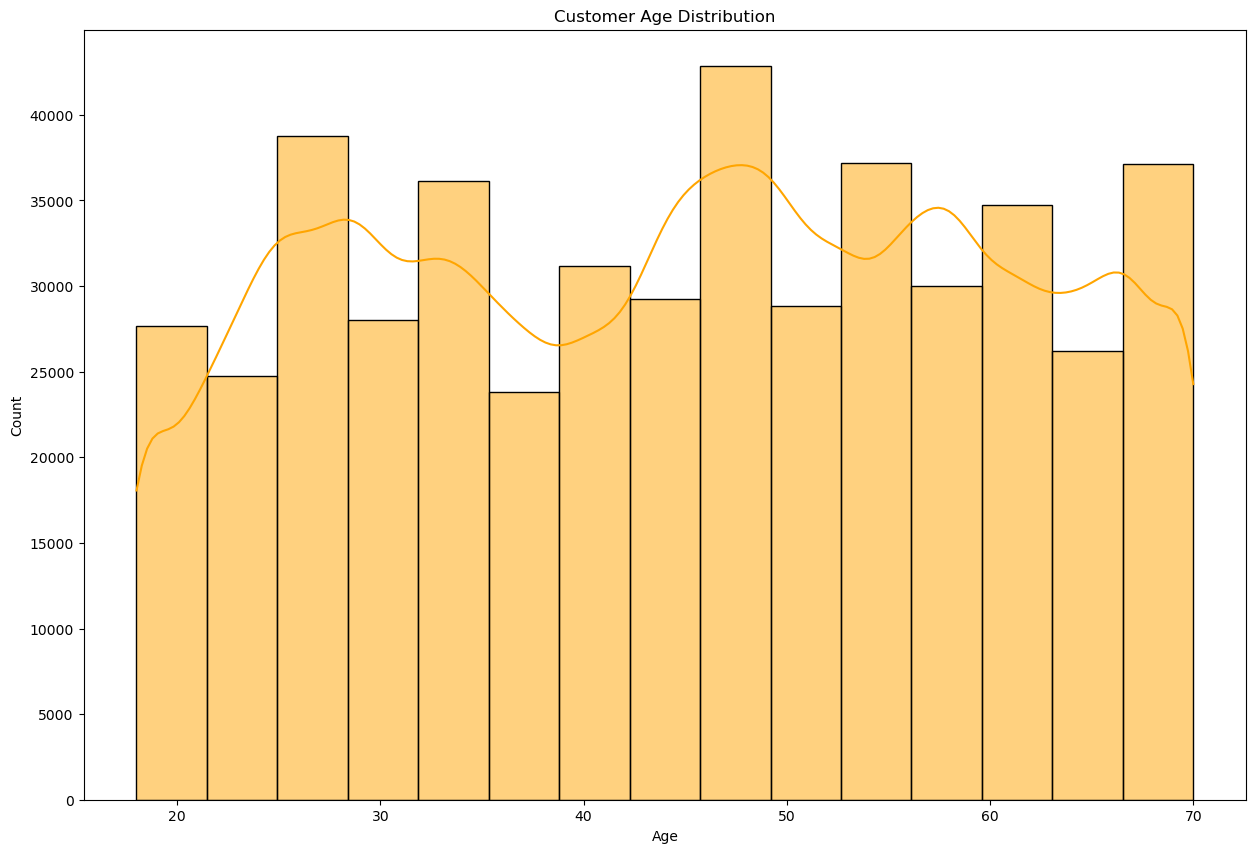

In [18]:
# ------------------------------------------
# 1. AGE DISTRIBUTION
# ------------------------------------------

print("\nVisualization 1 : Customer Age Distribution")
print("Q1. Highest Age Group :", df["Age"].mode()[0])
print("Q2. Average Age :", round(df["Age"].mean(),1))

plt.figure(figsize=(15,10))
sns.histplot(df["Age"], bins=15, kde=True , color = 'orange')
plt.title("Customer Age Distribution")
plt.show()


Visualization 2 : Annual Income Distribution
Q1. Most Common Income : 83091
Q2. Maximum Income : 171026


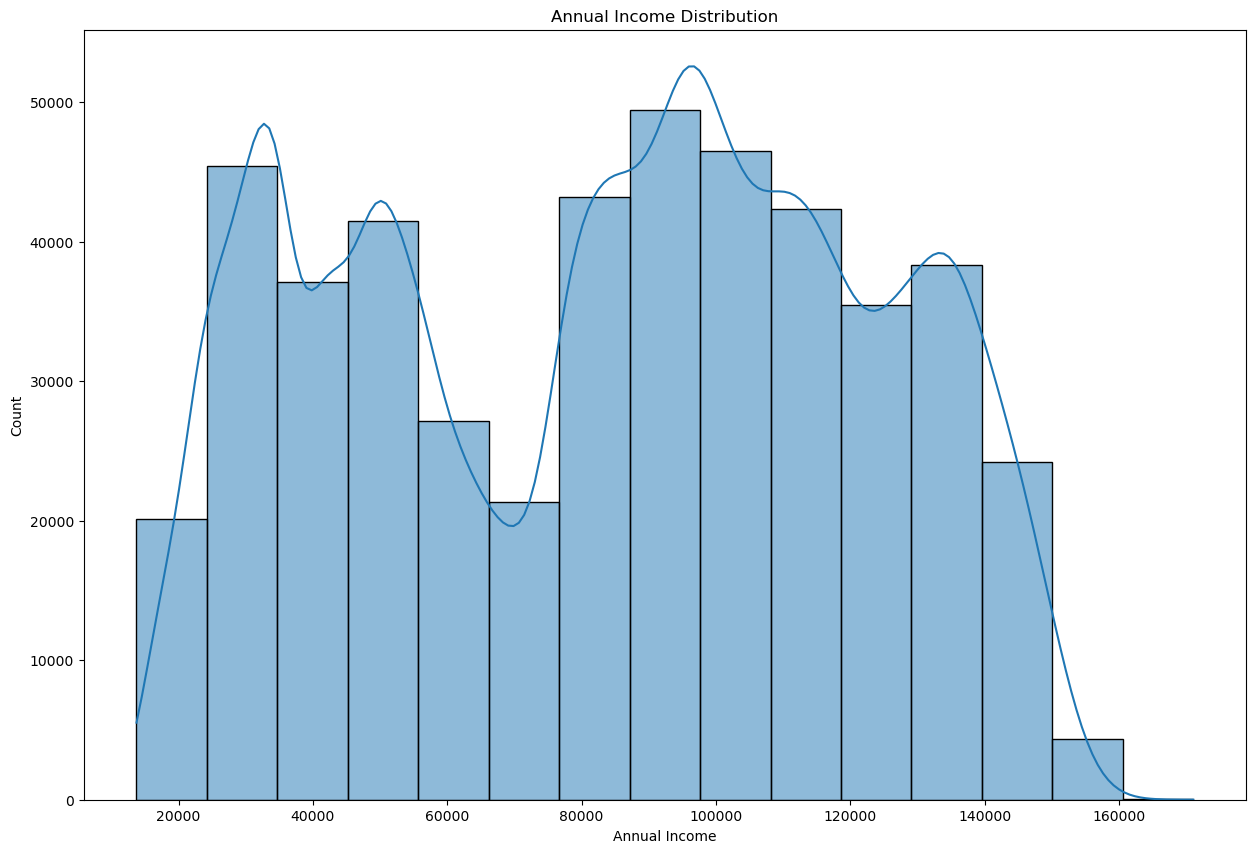

In [19]:
# ------------------------------------------
# 2. ANNUAL INCOME
# ------------------------------------------

print("\nVisualization 2 : Annual Income Distribution")
print("Q1. Most Common Income :", round(df["Annual Income"].mode()[0],2))
print("Q2. Maximum Income :", df["Annual Income"].max())

plt.figure(figsize=(15,10))
sns.histplot(df["Annual Income"], bins=15, kde=True)
plt.title("Annual Income Distribution")
plt.show()


Visualization 3 : Spending Score Distribution
Q1. Average Spending Score : 55.48
Q2. Spending Score Range : 1 - 100


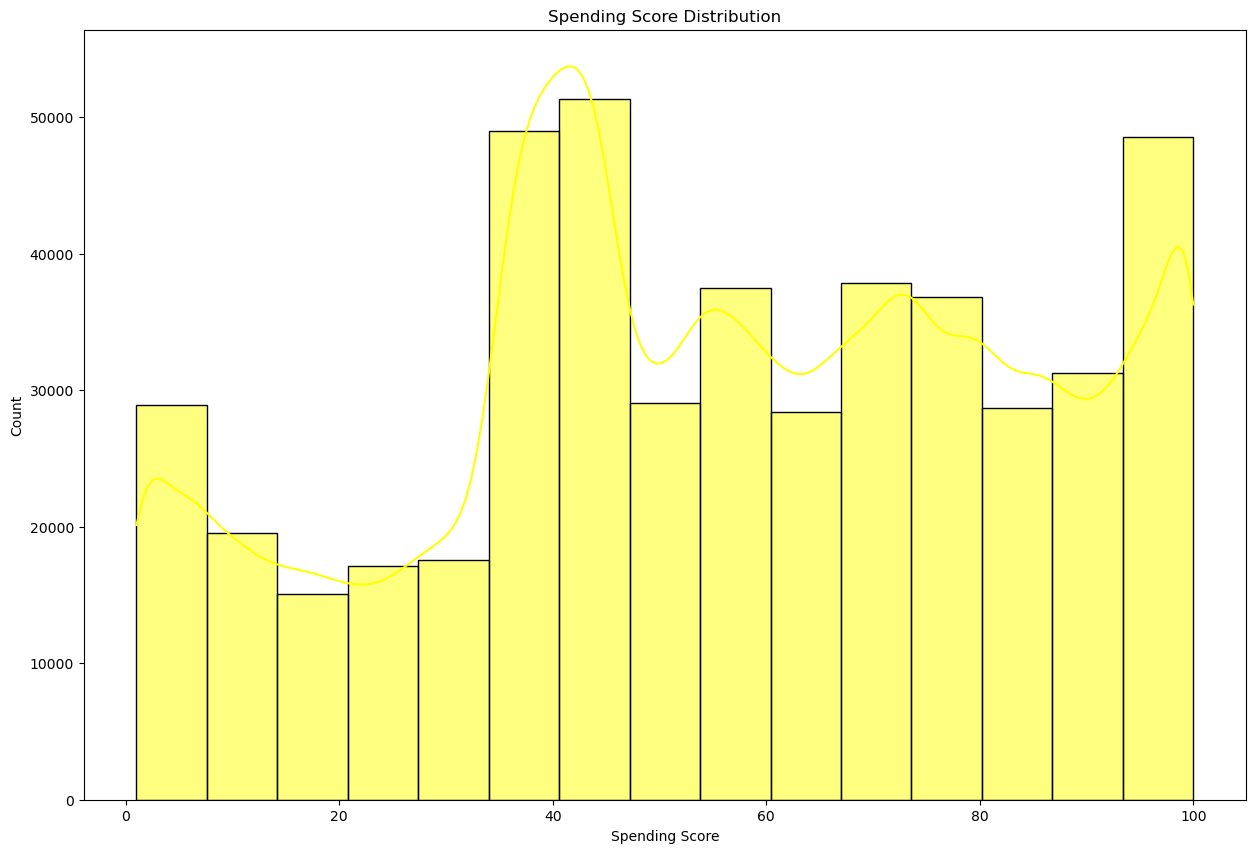

In [20]:
# ------------------------------------------
# 3. SPENDING SCORE
# ------------------------------------------

print("\nVisualization 3 : Spending Score Distribution")
print("Q1. Average Spending Score :", round(df["Spending Score"].mean(),2))
print("Q2. Spending Score Range :", df["Spending Score"].min(), "-", df["Spending Score"].max())

plt.figure(figsize=(15,10))
sns.histplot(df["Spending Score"], bins=15, kde=True , color = 'yellow')
plt.title("Spending Score Distribution")
plt.show()


Visualization 4 : Gender Distribution
Gender
1    50.8
0    49.2
Name: proportion, dtype: float64


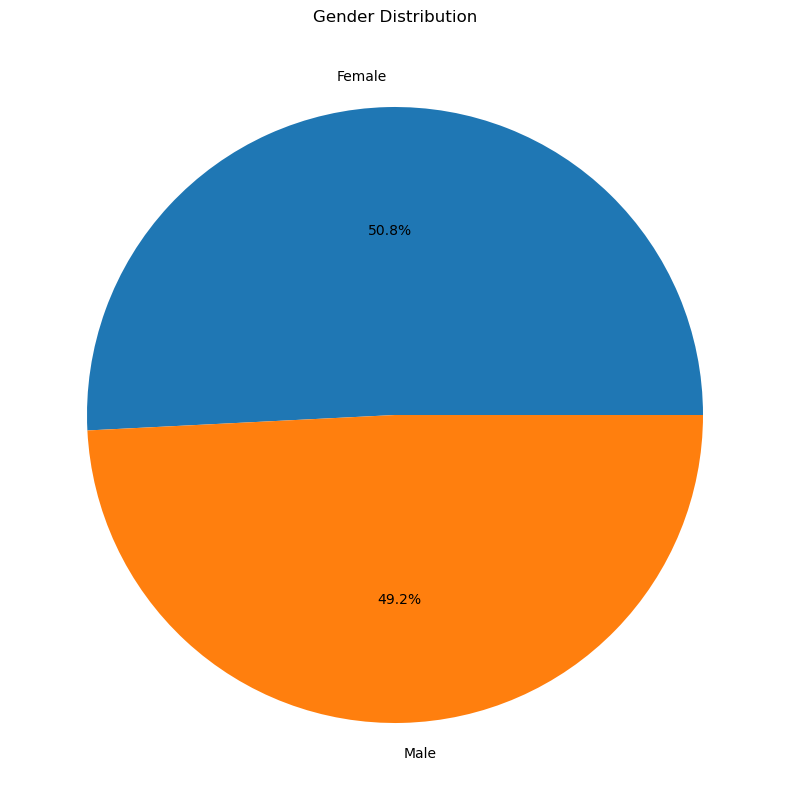

In [21]:
# ------------------------------------------
# 4. GENDER DISTRIBUTION
# ------------------------------------------

print("\nVisualization 4 : Gender Distribution")
print(df["Gender"].value_counts(normalize=True)*100)

plt.figure(figsize=(15,10))
df["Gender"].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=["Female","Male"],
    ylabel=""
)
plt.title("Gender Distribution")
plt.show()


Visualization 5 : Income vs Spending Score
Q1. Correlation : 0.19
Q2. Customer groups can be visually observed from the scatter plot.


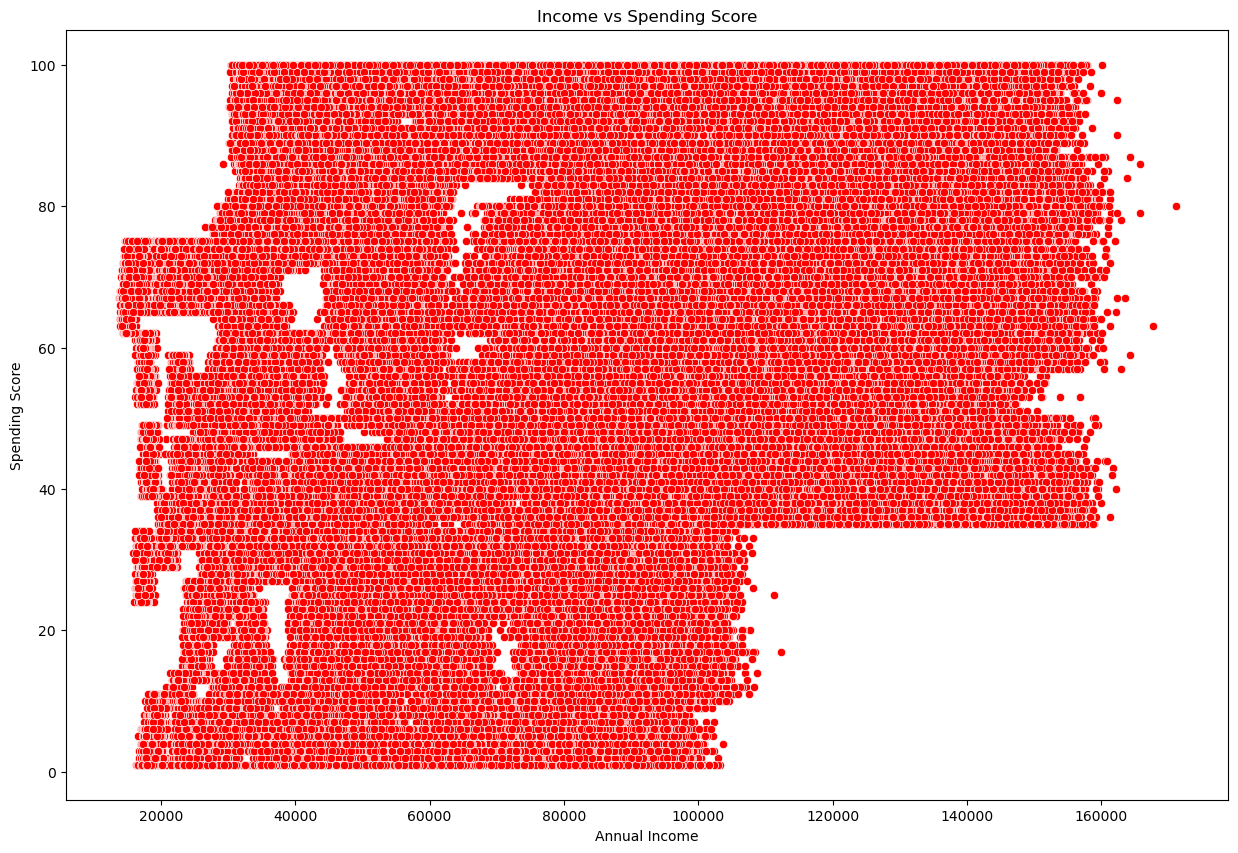

In [22]:
# ------------------------------------------
# 5. INCOME VS SPENDING
# ------------------------------------------

print("\nVisualization 5 : Income vs Spending Score")
print("Q1. Correlation :", round(df["Annual Income"].corr(df["Spending Score"]),2))
print("Q2. Customer groups can be visually observed from the scatter plot.")

plt.figure(figsize=(15,10))
sns.scatterplot(data=df,
                x="Annual Income",
                y="Spending Score" , color = 'red')
plt.title("Income vs Spending Score")
plt.show()


Visualization 6 : Membership Years
Average Membership : 7.7 Years
Maximum Membership : 16 Years


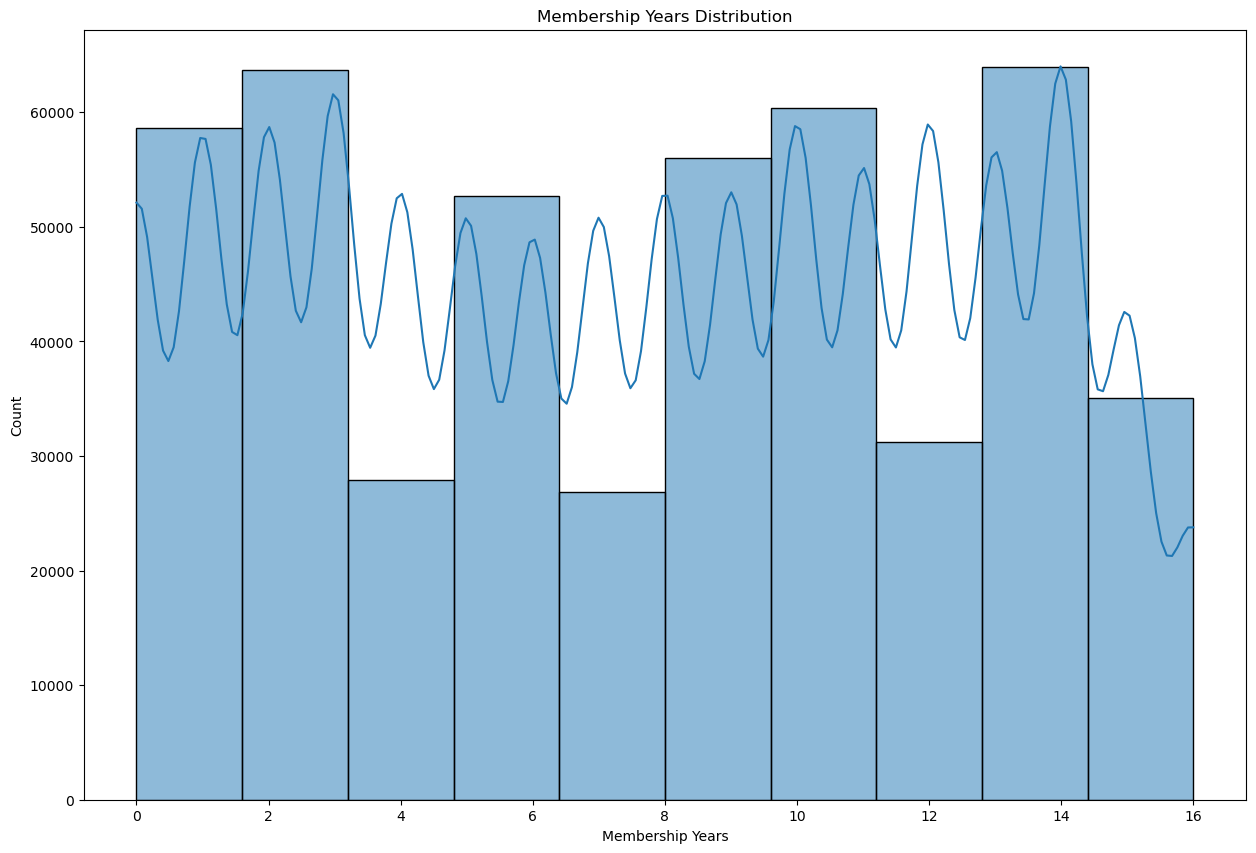

In [23]:
# ------------------------------------------
# 6. MEMBERSHIP YEARS
# ------------------------------------------

print("\nVisualization 6 : Membership Years")
print("Average Membership :", round(df["Membership Years"].mean(),2),"Years")
print("Maximum Membership :", df["Membership Years"].max(),"Years")

plt.figure(figsize=(15,10))
sns.histplot(df["Membership Years"], bins=10, kde=True)
plt.title("Membership Years Distribution")
plt.show()


Visualization 7 : Pair Plot
Relationship among Age, Income, Spending Score and Membership Years.


E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
E:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
E:\anaconda\Lib\site

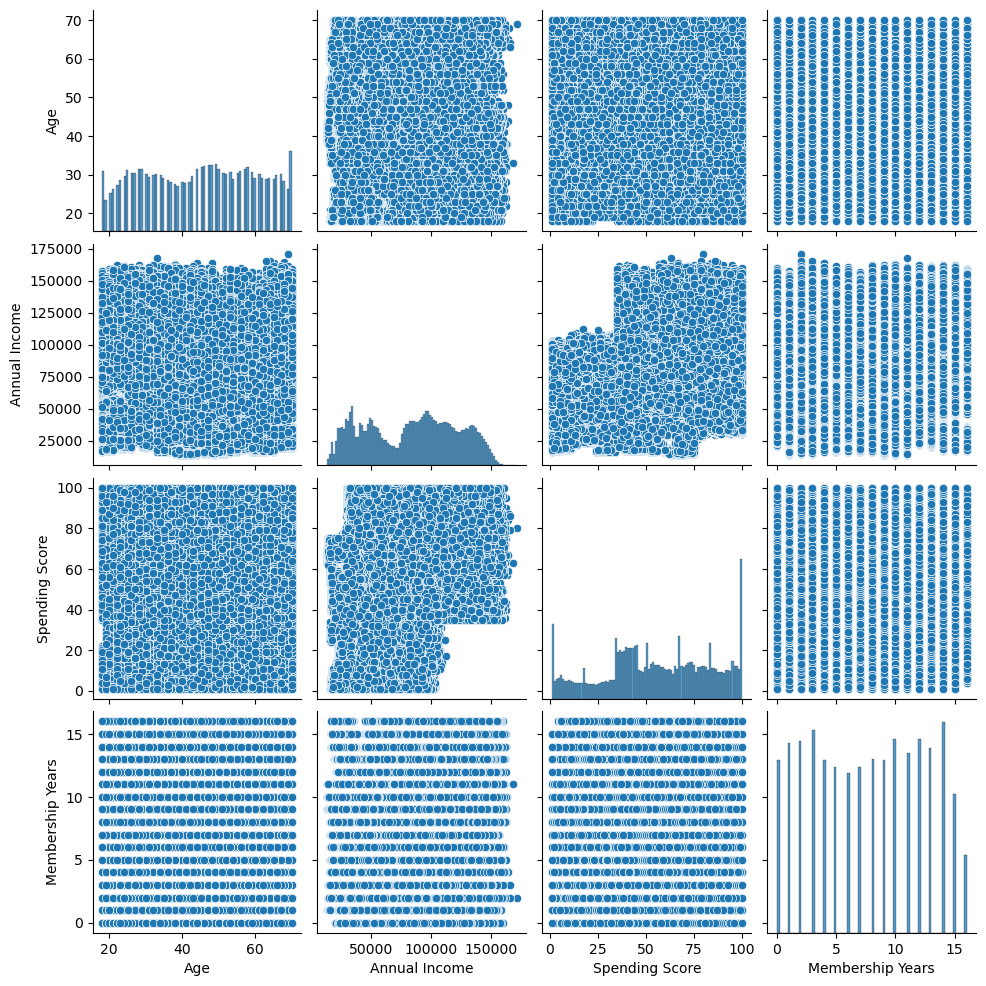

In [24]:
# ------------------------------------------
# 7. PAIR PLOT
# ------------------------------------------

print("\nVisualization 7 : Pair Plot")
print("Relationship among Age, Income, Spending Score and Membership Years.")

sns.pairplot(df[[
    "Age",
    "Annual Income",
    "Spending Score",
    "Membership Years"
]] , palette='Set2')
plt.show()


Visualization 8 : Correlation Heatmap
                       Age  Annual Income  Spending Score  Membership Years
Age               1.000000       0.038603       -0.036339          0.011684
Annual Income     0.038603       1.000000        0.189082          0.071553
Spending Score   -0.036339       0.189082        1.000000          0.048485
Membership Years  0.011684       0.071553        0.048485          1.000000


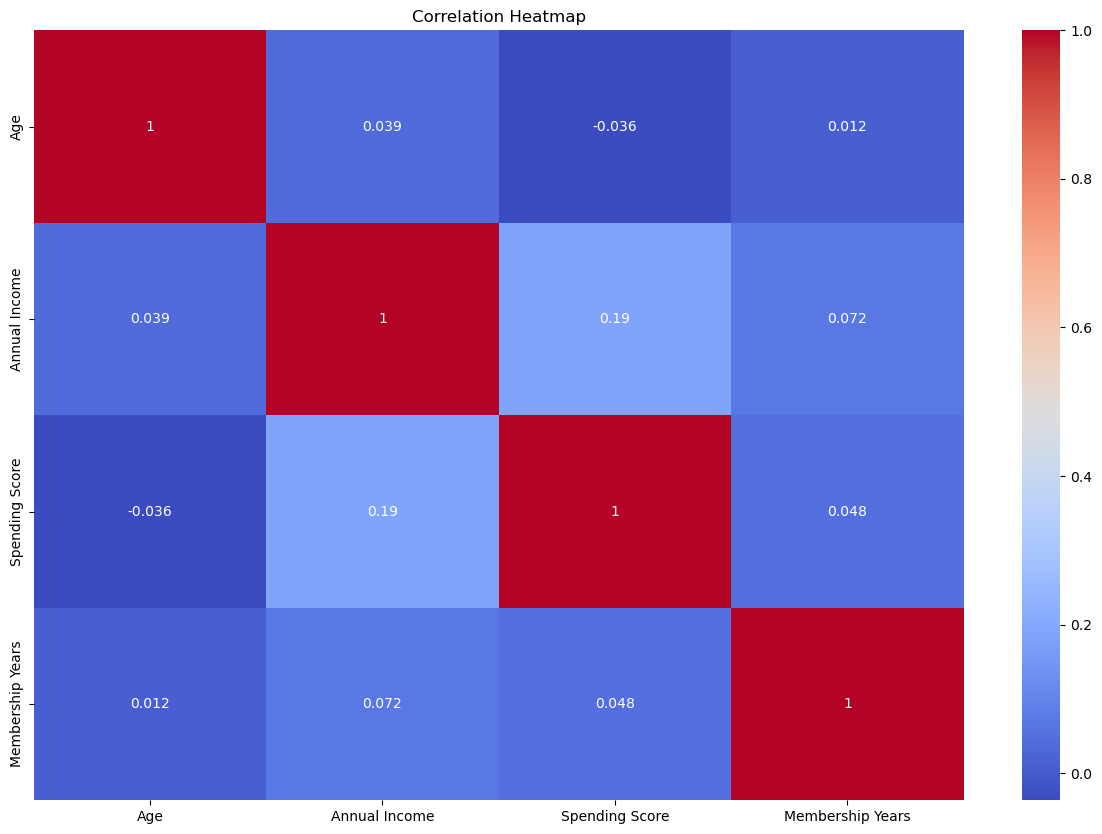

In [25]:
# ------------------------------------------
# 8. CORRELATION HEATMAP
# ------------------------------------------

print("\nVisualization 8 : Correlation Heatmap")

corr = df[[
    "Age",
    "Annual Income",
    "Spending Score",
    "Membership Years"
]].corr()

print(corr)

plt.figure(figsize=(15,10))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
#  FEATURE SCALING
# ==========================================

In [26]:
# Features used for clustering
features = ["Age", "Annual Income", "Spending Score", "Membership Years"]

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# Convert scaled data into a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)

# Display first 5 rows
print("Scaled Dataset:")
print(scaled_df.head())

Scaled Dataset:
        Age  Annual Income  Spending Score  Membership Years
0  0.688947      -1.656919        0.343542          0.273647
1 -1.108392      -1.276324        0.776561          1.323931
2 -1.374665      -0.295722        0.235288         -1.616864
3  0.955220      -0.168253        0.127033          0.273647
4  1.620901       0.989101        0.018779          0.063591


# ==========================================
# FINDING THE OPTIMAL NUMBER OF CLUSTERS
# ==========================================

In [ ]:
wcss = []

# Calculate WCSS for K = 1 to 10
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_df)
    wcss.append(model.inertia_)

In [ ]:
# Display WCSS values
print("WCSS Values")
for i, value in enumerate(wcss, start=1):
    print(f"K = {i} --> WCSS = {value:.2f}")

In [ ]:
# Select the elbow point (change if your graph suggests another K)
optimal_k = 4

# Plot Elbow Curve
plt.figure(figsize=(15,10))
plt.plot(range(1,11), wcss, marker='o', linewidth=2)
plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=120, label=f'Optimal K = {optimal_k}')

# Annotate the selected point
plt.annotate(f'Elbow Point\nK = {optimal_k}',
             xy=(optimal_k, wcss[optimal_k-1]),
             xytext=(optimal_k+0.5, wcss[optimal_k-1]+100),
             arrowprops=dict(arrowstyle='->'))

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Business Explanation
print("\nExplanation:")
print(f"The elbow point is observed around K = {optimal_k}.")
print("After this point, the decrease in WCSS becomes much smaller.")
print("Therefore, adding more clusters does not significantly improve the model.")
print(f"Hence, K = {optimal_k} is selected as the optimal number of clusters.")

# ==========================================
#  BUILD K-MEANS CLUSTERING MODEL
# ==========================================

In [ ]:
# Train the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign each customer to a cluster
df["Cluster"] = kmeans.fit_predict(scaled_df)

# Display first few clustered records
print("First 10 Clustered Records")
print(df.head(10))

# Number of customers in each cluster
print("\nCustomers in Each Cluster")
print(df["Cluster"].value_counts().sort_index())

# ==========================================
#  VISUALIZE CUSTOMER CLUSTERS
# ==========================================

In [ ]:
# Scatter Plot of Customer Segments
plt.figure(figsize=(15,10))

sns.scatterplot(
    data=df,
    x="Annual Income",
    y="Spending Score",
    hue="Cluster",
    palette="Set1",
    s=80
)
plt.show()

In [ ]:
# Plot Cluster Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(15,10))
plt.scatter(
    centroids[:,1],        # Annual Income
    centroids[:,2],        # Spending Score
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments using K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)

plt.show()

# Display Cluster Names
print("\nCustomer Segments")
for i in sorted(df["Cluster"].unique()):
    print(f"Cluster {i+1}")

# ==========================================
# CLUSTER ANALYSIS
# ==========================================

In [ ]:
# Analyze each cluster
cluster_summary = df.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income":"mean",
    "Spending Score":"mean",
    "Membership Years":"mean",
    "Customer ID":"count"
}).round(2)

# Rename column
cluster_summary.rename(columns={"Customer ID":"Number of Customers"}, inplace=True)

# Display Summary Table
print("Cluster Analysis")
print(cluster_summary)

# ==========================================
#  BUSINESS INTERPRETATION
# ==========================================

In [ ]:
# Assign business names to each cluster
cluster_names = {
    0: "Premium Customers",
    1: "Budget Customers",
    2: "High Spenders",
    3: "New Customers"
}

# Create a new column
df["Customer Segment"] = df["Cluster"].map(cluster_names)

# Display sample records
print(df[["Customer ID", "Cluster", "Customer Segment"]].head(10))

# Number of customers in each segment
print("\nCustomer Segments")
print(df["Customer Segment"].value_counts())

In [ ]:
business_summary = {
    "Premium Customers": {
        "Characteristics": "High Income, High Spending Score, Long Membership",
        "Recommendation": "Offer VIP memberships, exclusive discounts, early access to new products, and premium loyalty rewards."
    },

    "Budget Customers": {
        "Characteristics": "Low Income, Low Spending Score",
        "Recommendation": "Provide coupons, discounts, cashback offers, and affordable product bundles."
    },

    "High Spenders": {
        "Characteristics": "Moderate Income, Very High Spending Score",
        "Recommendation": "Recommend complementary products, personalized offers, and cross-selling campaigns."
    },

    "New Customers": {
        "Characteristics": "Short Membership Duration, Moderate Spending",
        "Recommendation": "Provide welcome offers, onboarding emails, referral bonuses, and introductory discounts."
    }
}

for segment, details in business_summary.items():
    print("\n" + "="*60)
    print(segment)
    print("="*60)
    print("Characteristics :", details["Characteristics"])
    print("Recommendation  :", details["Recommendation"])

# ==========================================
#  BUSINESS RECOMMENDATIONS
# ==========================================

In [ ]:
recommendations = {
    "Premium Customers":
        "Reward with VIP memberships, exclusive discounts, premium loyalty points, and early access to new products.",

    "Budget Customers":
        "Provide coupons, cashback offers, seasonal discounts, and affordable product bundles to increase purchases.",

    "High Spenders":
        "Use personalized recommendations, cross-selling, upselling, and premium product suggestions.",

    "New Customers":
        "Offer welcome discounts, referral bonuses, onboarding emails, and first-purchase incentives."
}

print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)


for segment, recommendation in recommendations.items():
    print(f"\n{segment}")
    print("-"*70)
    print(recommendation)

print("\nOverall Business Recommendations")
print("-"*70)

overall = [
    "Launch targeted marketing campaigns for each customer segment.",
    "Reward premium customers with exclusive loyalty benefits.",
    "Re-engage budget customers using promotional offers and coupons.",
    "Increase revenue through cross-selling and upselling for high spenders.",
    "Create onboarding campaigns for new customers to improve retention.",
    "Use customer segmentation to improve marketing ROI and customer satisfaction."
]

for i, recommendation in enumerate(overall, start=1):
    print(f"{i}. {recommendation}")